실습 6. 불규칙 주기 정규화 종합 리포트
- 측정 기간·결측·최장 연속 결측을 담은 진단 리포트

목표
- 측정 기간·시점 수·결측·가장 긴 연속 결측을 담은 시간축 진단 리포트를 작성

단계
- 정규화 데이터의 측정 기간과 시점 수를 출력
- 결측 개수와 비율을 정리
- 빈 값이 연속으로 이어진 가장 긴 길이를 구하기

예상 결과
- 200시점·결측 22칸(11퍼센트), 가장 긴 연속 결측은 10칸

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv('../data/22_열처리.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

측정 기간: 2024-03-01 09:00:00 ~ 2024-03-01 09:33:10
시점 수: 200 / 결측: {'제어출력': 22, '소입로온도': 22}
결측 비율(%): {'제어출력': 11.0, '소입로온도': 11.0}
가장 긴 연속 결측(칸): 10


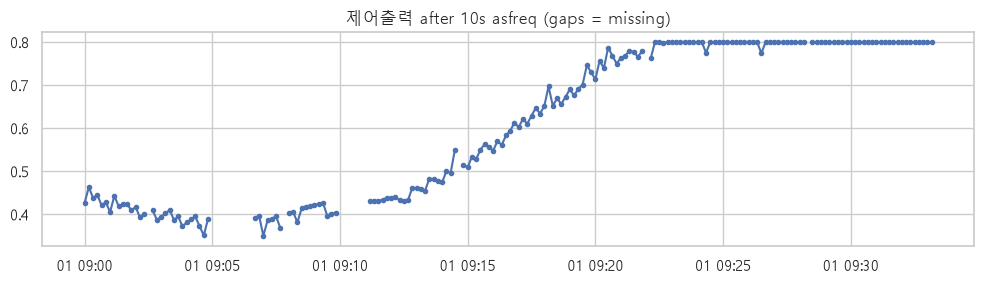

In [6]:
# [최장 연속 결측 구간 검출 알고리즘 및 격자 결측 최종 리포트 출력]
# 1. `isna != isna.shift()`: 결측 여부 신호가 직전 시점과 바뀌는 변화점(경계)을 판단합니다.
# 2. `.cumsum()`: 누적 합계를 구해 서로 다른 결측/비결측 덩어리(Group)를 분류하는 새로운 번호를 매깁니다.
# 3. `isna.groupby(groups).sum().max()`: 뭉쳐있는 결측 구간 중 '가장 길게 연속으로 누락된 개수'를 정량 검출합니다. (최대 10칸 연속 누락)
# * 간헐적 결측은 단기 보간이 되지만, 연속 10칸(100초) 누락과 같이 거대 공백이 생긴 구간은
#   인접 데이터 기반 추정이 매우 부정확하므로, 보간 불가 대상(무효 처리 구간)으로 선포하여 오판을 방지해야 합니다.
# * `isna`는 불리언(True/False) 시리즈로, sum() 연산 시 True를 1로, False를 0으로 해석해 동작합니다.

# 정규화 데이터의 측정 기간과 시점 수를 출력
norm = df[['제어출력', '소입로온도']].asfreq('10s')
print('측정 기간:', norm.index.min(), '~', norm.index.max())
# 측정 기간: 2024-03-01 09:00:00 ~ 2024-03-01 09:33:10
print('시점 수:', len(norm), '/ 결측:', norm.isna().sum().to_dict())
# 시점 수: 200 / 결측: {'제어출력': 22, '소입로온도': 22}

# 결측 개수와 비율을 정리
print('결측 비율(%):', (norm.isna().mean() * 100).round(1).to_dict())
# 결측 비율(%): {'제어출력': 11.0, '소입로온도': 11.0}

# 빈 값이 연속으로 이어진 가장 긴 길이를 구하기
isna = norm['제어출력'].isna()
groups = (isna != isna.shift()).cumsum()
print('가장 긴 연속 결측(칸):', int(isna.groupby(groups).sum().max()))   # 10
# 가장 긴 연속 결측(칸): 10

# 결측 위치 그래프(검증용 savefig)
plt.figure(figsize=(10, 3))
plt.plot(norm.index, norm['제어출력'], marker='.')
plt.title('제어출력 after 10s asfreq (gaps = missing)')
plt.tight_layout()
plt.show()
